In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

<div style="background-color:black; color:white; padding:15px; border-radius:8px;">
<h3 style="color:Gold;">DLP Week 10 Object Detection</h3>
    You Only Look Ones -> Predict object class and location
    24 classes -> Flies on the surface images 
    
    Contains images of rice crop diseases and pests
</div>

<div style="background-color:black; color:white; padding:15px; border-radius:8px;">
<h3 style="color:gold;">Imports and Image Directory</h3>
    Ultralytics -> YOLO(yolo11n.pt)
</div>

In [43]:
!pip install ultralytics

In [33]:
import os
from sklearn.model_selection import train_test_split

In [10]:
df = pd.read_csv('/kaggle/input/week-10-object-detection/train.csv')

In [79]:
df.head()

,image_id,class_name,x_min,y_min,x_max,y_max,width,height,class_id
0,0000001.jpg,RiceLeafRoller,241,52,295,93,800,600,0
1,0000001.jpg,RiceLeafRoller,242,95,283,142,800,600,0
2,0000001.jpg,RiceLeafCaterpillar,157,379,185,410,800,600,1
3,0000002.jpg,PaddyStemMaggot,323,215,414,281,800,600,2
4,0000004.jpg,YellowRiceBorer,523,435,542,472,800,600,3



<div style="background-color:black; color:white; padding:15px; border-radius:8px;">
<h3 style="color:gold;">Length of train.csv (102472, 9)</h3>
</div>

In [83]:
# Train data
!ls /kaggle/input/week-10-object-detection/train | wc -l

12701


In [84]:
# Test data
!ls /kaggle/input/week-10-object-detection/test | wc -l

7600


In [17]:
class_names = list(df['class_name'].unique())

In [85]:
class_names

['RiceLeafRoller',
 'RiceLeafCaterpillar',
 'PaddyStemMaggot',
 'YellowRiceBorer',
 'RiceGallMidge',
 'RiceStemfly',
 'AsiaticRiceBorer',
 'BrownPlantHopper',
 'WhiteBackedPlantHopper',
 'SmallBrownPlantHopper',
 'RiceWaterWeevil',
 'RiceLeafhopper',
 'GrainSpreaderThrips',
 'RiceShellPest',
 'MoleCricket',
 'Grub',
 'Wireworm',
 'WhiteMarginedMoth',
 'BlackCutworm',
 'LargeCutworm',
 'RedSpider',
 'YellowCutworm',
 'CornBorer']

In [22]:
class_to_id = {}
for index, class_name in enumerate(class_names):
    class_to_id[class_name] = index

In [23]:
class_to_id

{'RiceLeafRoller': 0,
 'RiceLeafCaterpillar': 1,
 'PaddyStemMaggot': 2,
 'YellowRiceBorer': 3,
 'RiceGallMidge': 4,
 'RiceStemfly': 5,
 'AsiaticRiceBorer': 6,
 'BrownPlantHopper': 7,
 'WhiteBackedPlantHopper': 8,
 'SmallBrownPlantHopper': 9,
 'RiceWaterWeevil': 10,
 'RiceLeafhopper': 11,
 'GrainSpreaderThrips': 12,
 'RiceShellPest': 13,
 'MoleCricket': 14,
 'Grub': 15,
 'Wireworm': 16,
 'WhiteMarginedMoth': 17,
 'BlackCutworm': 18,
 'LargeCutworm': 19,
 'RedSpider': 20,
 'YellowCutworm': 21,
 'CornBorer': 22}

In [24]:
df["class_id"] = df["class_name"].map(class_to_id)

<div style="background-color:black; color:white; padding:15px; border-radius:8px;">
<h3 style="color:gold;">Train–Validation Split</h3>
</div>

In [26]:
ids = df["image_id"].unique()
train_ids, val_ids = train_test_split(ids, test_size=0.2, random_state=42)

In [31]:
print(train_ids.shape)
print(val_ids.shape)

(10160,)
(2541,)


<div style="background-color:black; color:white; padding:15px; border-radius:8px;">
<h3 style="color:gold;">Create Images and Labels Directory</h3>
</div>

In [34]:
os.makedirs("/kaggle/working/images/train", exist_ok=True)
os.makedirs("/kaggle/working/images/val", exist_ok=True)
os.makedirs("/kaggle/working/labels/train", exist_ok=True)
os.makedirs("/kaggle/working/labels/val", exist_ok=True)

<div style="background-color:black; color:white; padding:15px; border-radius:8px;">
<h3 style="color:gold;">Shutil -> Copy train images to working</h3>
</div>

In [35]:
import shutil

In [37]:
def create_labels(image_list, split):
    for img in image_list:

        shutil.copy(f"/kaggle/input/week-10-object-detection/train/{img}",
                    f"/kaggle/working/images/{split}/{img}")
        
        
        sub = df[df["image_id"] == img]
        
        w = sub["width"].values[0]
        h = sub["height"].values[0]
        
        label_path = f"/kaggle/working/labels/{split}/{img.replace('.jpg','.txt')}"
        with open(label_path, "w") as f:
            for _, row in sub.iterrows():
                xc = (row.x_min + row.x_max) / 2 / w
                yc = (row.y_min + row.y_max) / 2 / h
                bw = (row.x_max - row.x_min) / w
                bh = (row.y_max - row.y_min) / h

                f.write(f"{row.class_id} {xc} {yc} {bw} {bh}\n")

create_labels(train_ids, "train")
create_labels(val_ids, "val")

<div style="background-color:black; color:white; padding:15px; border-radius:8px;">
<h3 style="color:gold;">data.yaml file with number of classes = 24</h3>
</div>

In [38]:
yaml_content = """
train: images/train
val: images/val

nc: 24
names:
  - RiceLeafRoller
  - RiceLeafCaterpillar
  - PaddyStemMaggot
  - AsiaticRiceBorer
  - YellowRiceBorer
  - RiceGallMidge
  - RiceStemfly
  - BrownPlantHopper
  - WhiteBackedPlantHopper
  - SmallBrownPlantHopper
  - RiceWaterWeevil
  - RiceBlackBug
  - Aphids
  - GreenLeafHoppers
  - MealyBugs
  - RiceHornedCaterpillar
  - RiceCaseWorm
  - RiceLeafFolder
  - RiceStemborer
  - RiceGrasshopper
  - RiceBrownSpot
  - RiceBlast
  - RiceHispa
  - RiceFalseSmut
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

<div style="background-color:black; color:white; padding:15px; border-radius:8px;">
<h3 style="color:gold;">Import Ultralytics</h3>
</div>

In [45]:
from ultralytics import YOLO

In [55]:
model = YOLO("yolo11n.pt")

In [57]:
model.train(
    data="/kaggle/working/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    patience=20
)

Ultralytics 8.3.235 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12.0,

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       2541      21932      0.581      0.418      0.416      0.247
        RiceLeafRoller        891       2701      0.632       0.78      0.768      0.466
   RiceLeafCaterpillar        607       1854      0.496      0.768      0.672      0.397
       PaddyStemMaggot        315        522      0.913      0.921      0.955      0.602
      AsiaticRiceBorer        191        666       0.69       0.66      0.662       0.36
       YellowRiceBorer          7         14          1          0     0.0337     0.0148
         RiceGallMidge        834       3616      0.457      0.634      0.543      0.276
           RiceStemfly        275        487      0.727      0.688      0.766      0.522
      BrownPlantHopper        345        498      0.257      0.321      0.202       0.14
WhiteBackedPlantHopper        387        864      0.555      0.617      0.609      0.404
 SmallBrownPlantHopper        156        194      0.153      0.149      0.122      0.081
       RiceWaterWeevi

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7916f17406d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.0420

In [ ]:
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

results = model.predict(
    source="/kaggle/input/week-10-object-detection/test",
    imgsz=640,
    conf=0.1
)


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/7600 /kaggle/input/week-10-object-detection/test/0000003.jpg: 480x640 25 RiceLeafCaterpillars, 1 AsiaticRiceBorer, 4 RiceGallMidges, 2 RiceStemflys, 1 BrownPlantHopper, 1 RiceHispa, 47.0ms
image 2/7600 /kaggle/input/week-10-object-detection/test/0000010.jpg: 480x640 2 RiceLeafCaterpillars, 1 PaddyStemMaggot, 26 AsiaticRiceBorers, 1 RiceGallMidge, 8.5ms
image 3/7600 /kaggle/input/week-10-object-detection/test/0000012.jpg: 480x640 3 RiceLeafRolle

<div style="background-color:black; color:white; padding:15px; border-radius:8px;">
<h3 style="color:gold;">Extracting prediction from results</h3>
    class confidence x1 y1 x2 y2
</div>

In [59]:
import pandas as pd

sub = []

for r in results:
    img = os.path.basename(r.path)
    preds = []

    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        class_name = class_names[cls]
        preds.append(f"{class_name} {conf:.4f} {x1:.0f} {y1:.0f} {x2:.0f} {y2:.0f}")

    pred_str = " ".join(preds)
    sub.append([img, pred_str])

df_sub = pd.DataFrame(sub, columns=["ImageID", "PredictionString"])
df_sub.to_csv("/kaggle/working/submission.csv", index=False)

In [60]:
submission_file = pd.read_csv('/kaggle/working/submission.csv')

<div style="background-color:black; color:white; padding:15px; border-radius:8px;">
<h3 style="color:gold;">Submission File</h3>
</div>

In [61]:
submission_file.head()

,ImageID,PredictionString
0,0000003.jpg,AsiaticRiceBorer 0.6617 281 409 336 469 RiceLe...
1,0000010.jpg,YellowRiceBorer 0.9040 358 342 384 382 YellowR...
2,0000012.jpg,RiceLeafRoller 0.7766 222 139 270 209 RiceStem...
3,0000019.jpg,YellowRiceBorer 0.9649 336 455 363 491 YellowR...
4,0000021.jpg,YellowRiceBorer 0.9191 430 172 464 199 YellowR...


In [62]:
submission_file.shape

(7600, 2)

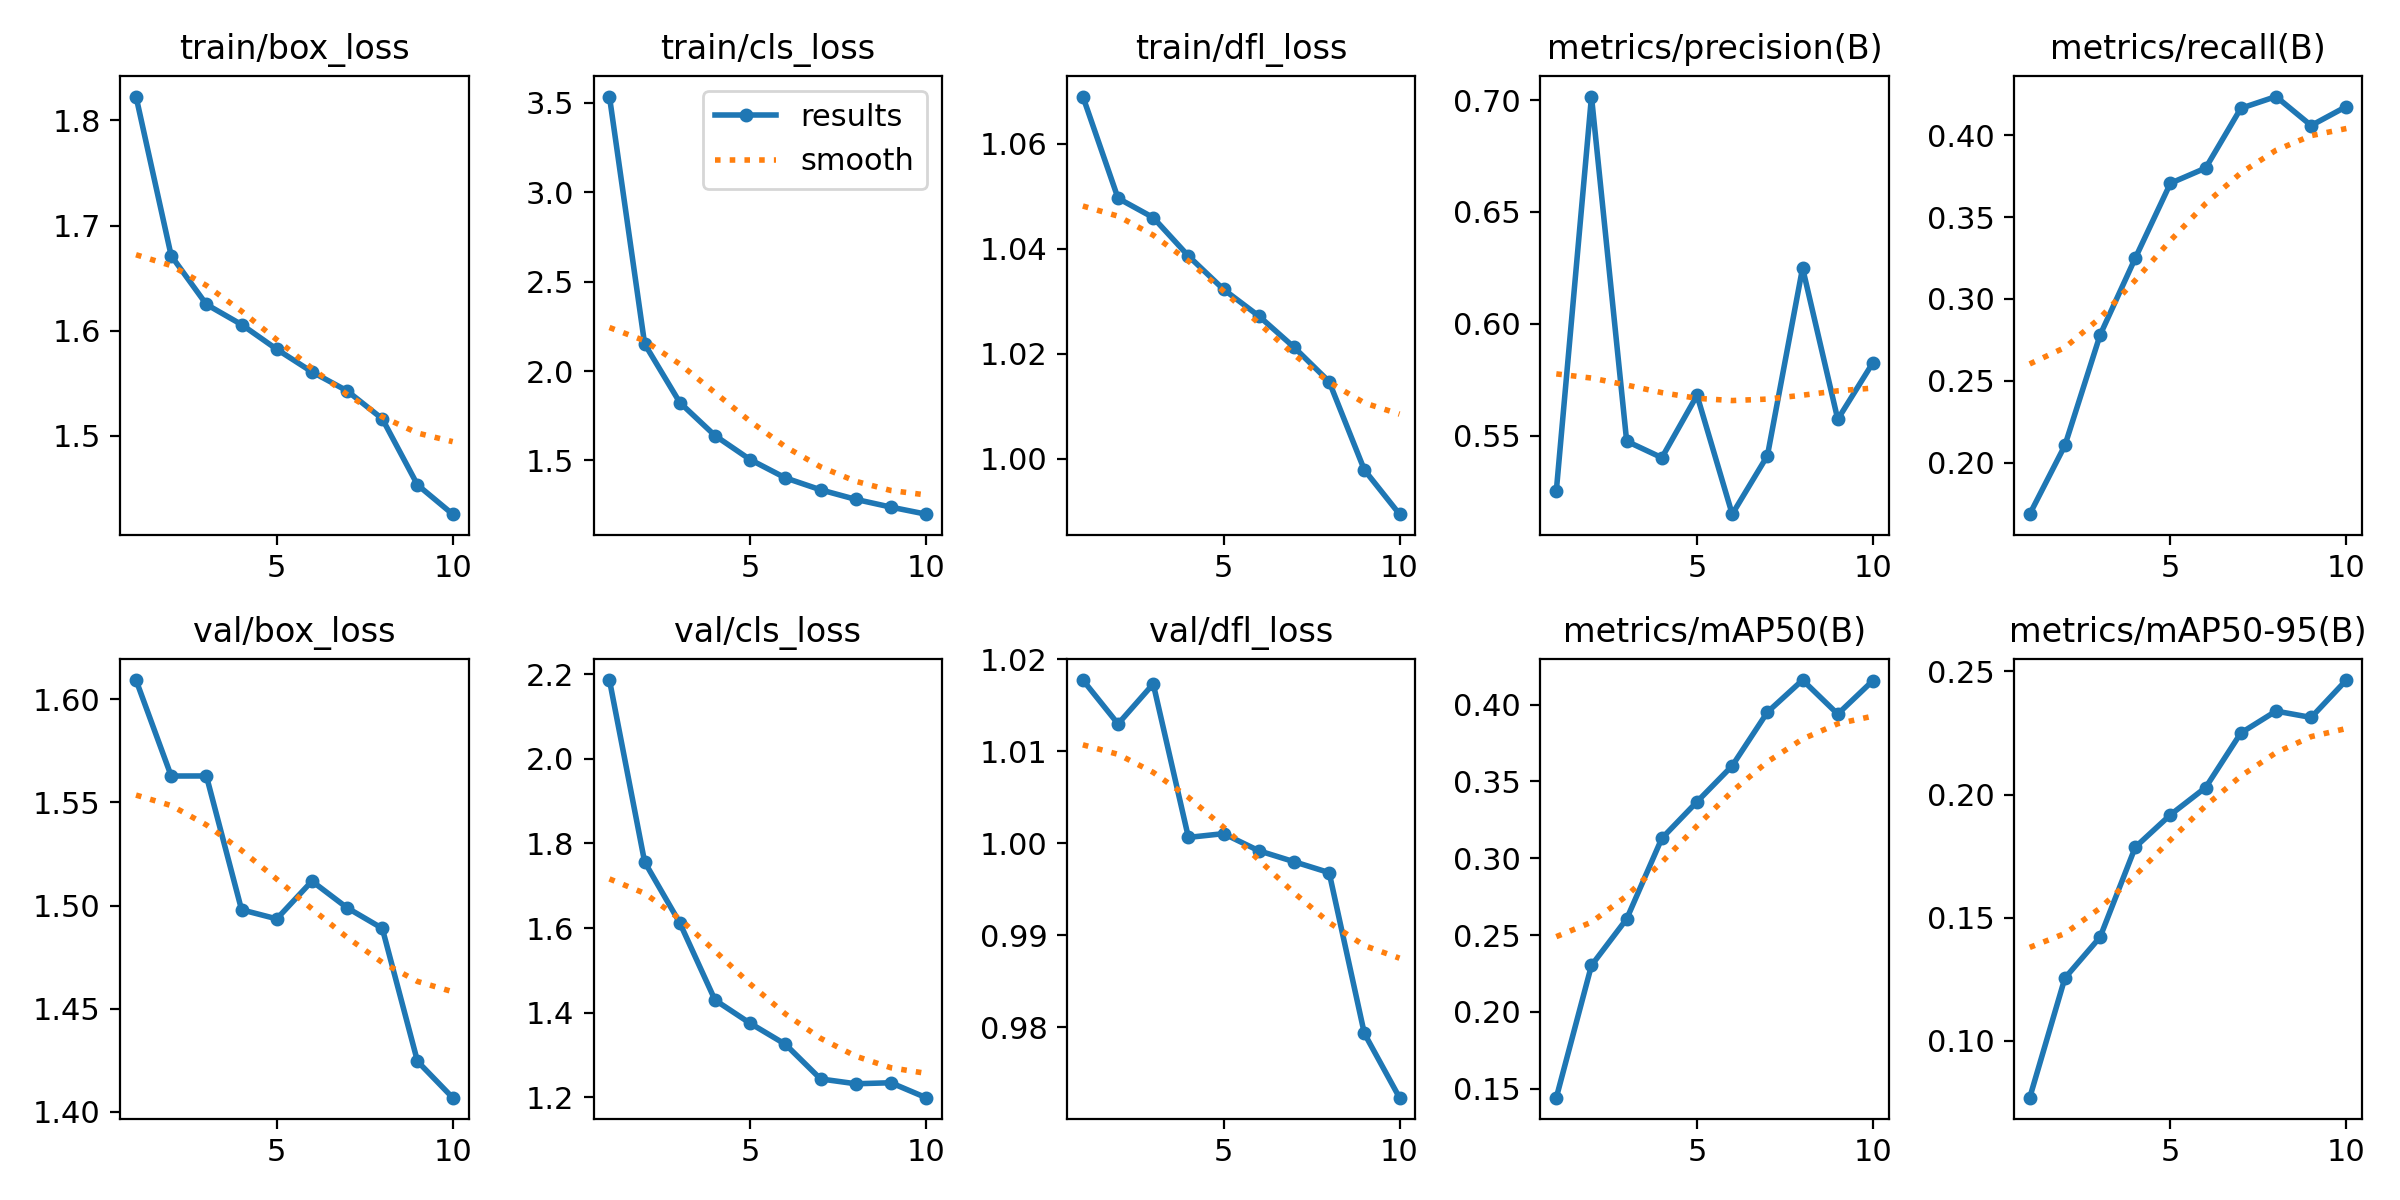

In [70]:
from IPython.display import Image, display
display(Image('/kaggle/working/runs/detect/train/results.png'))

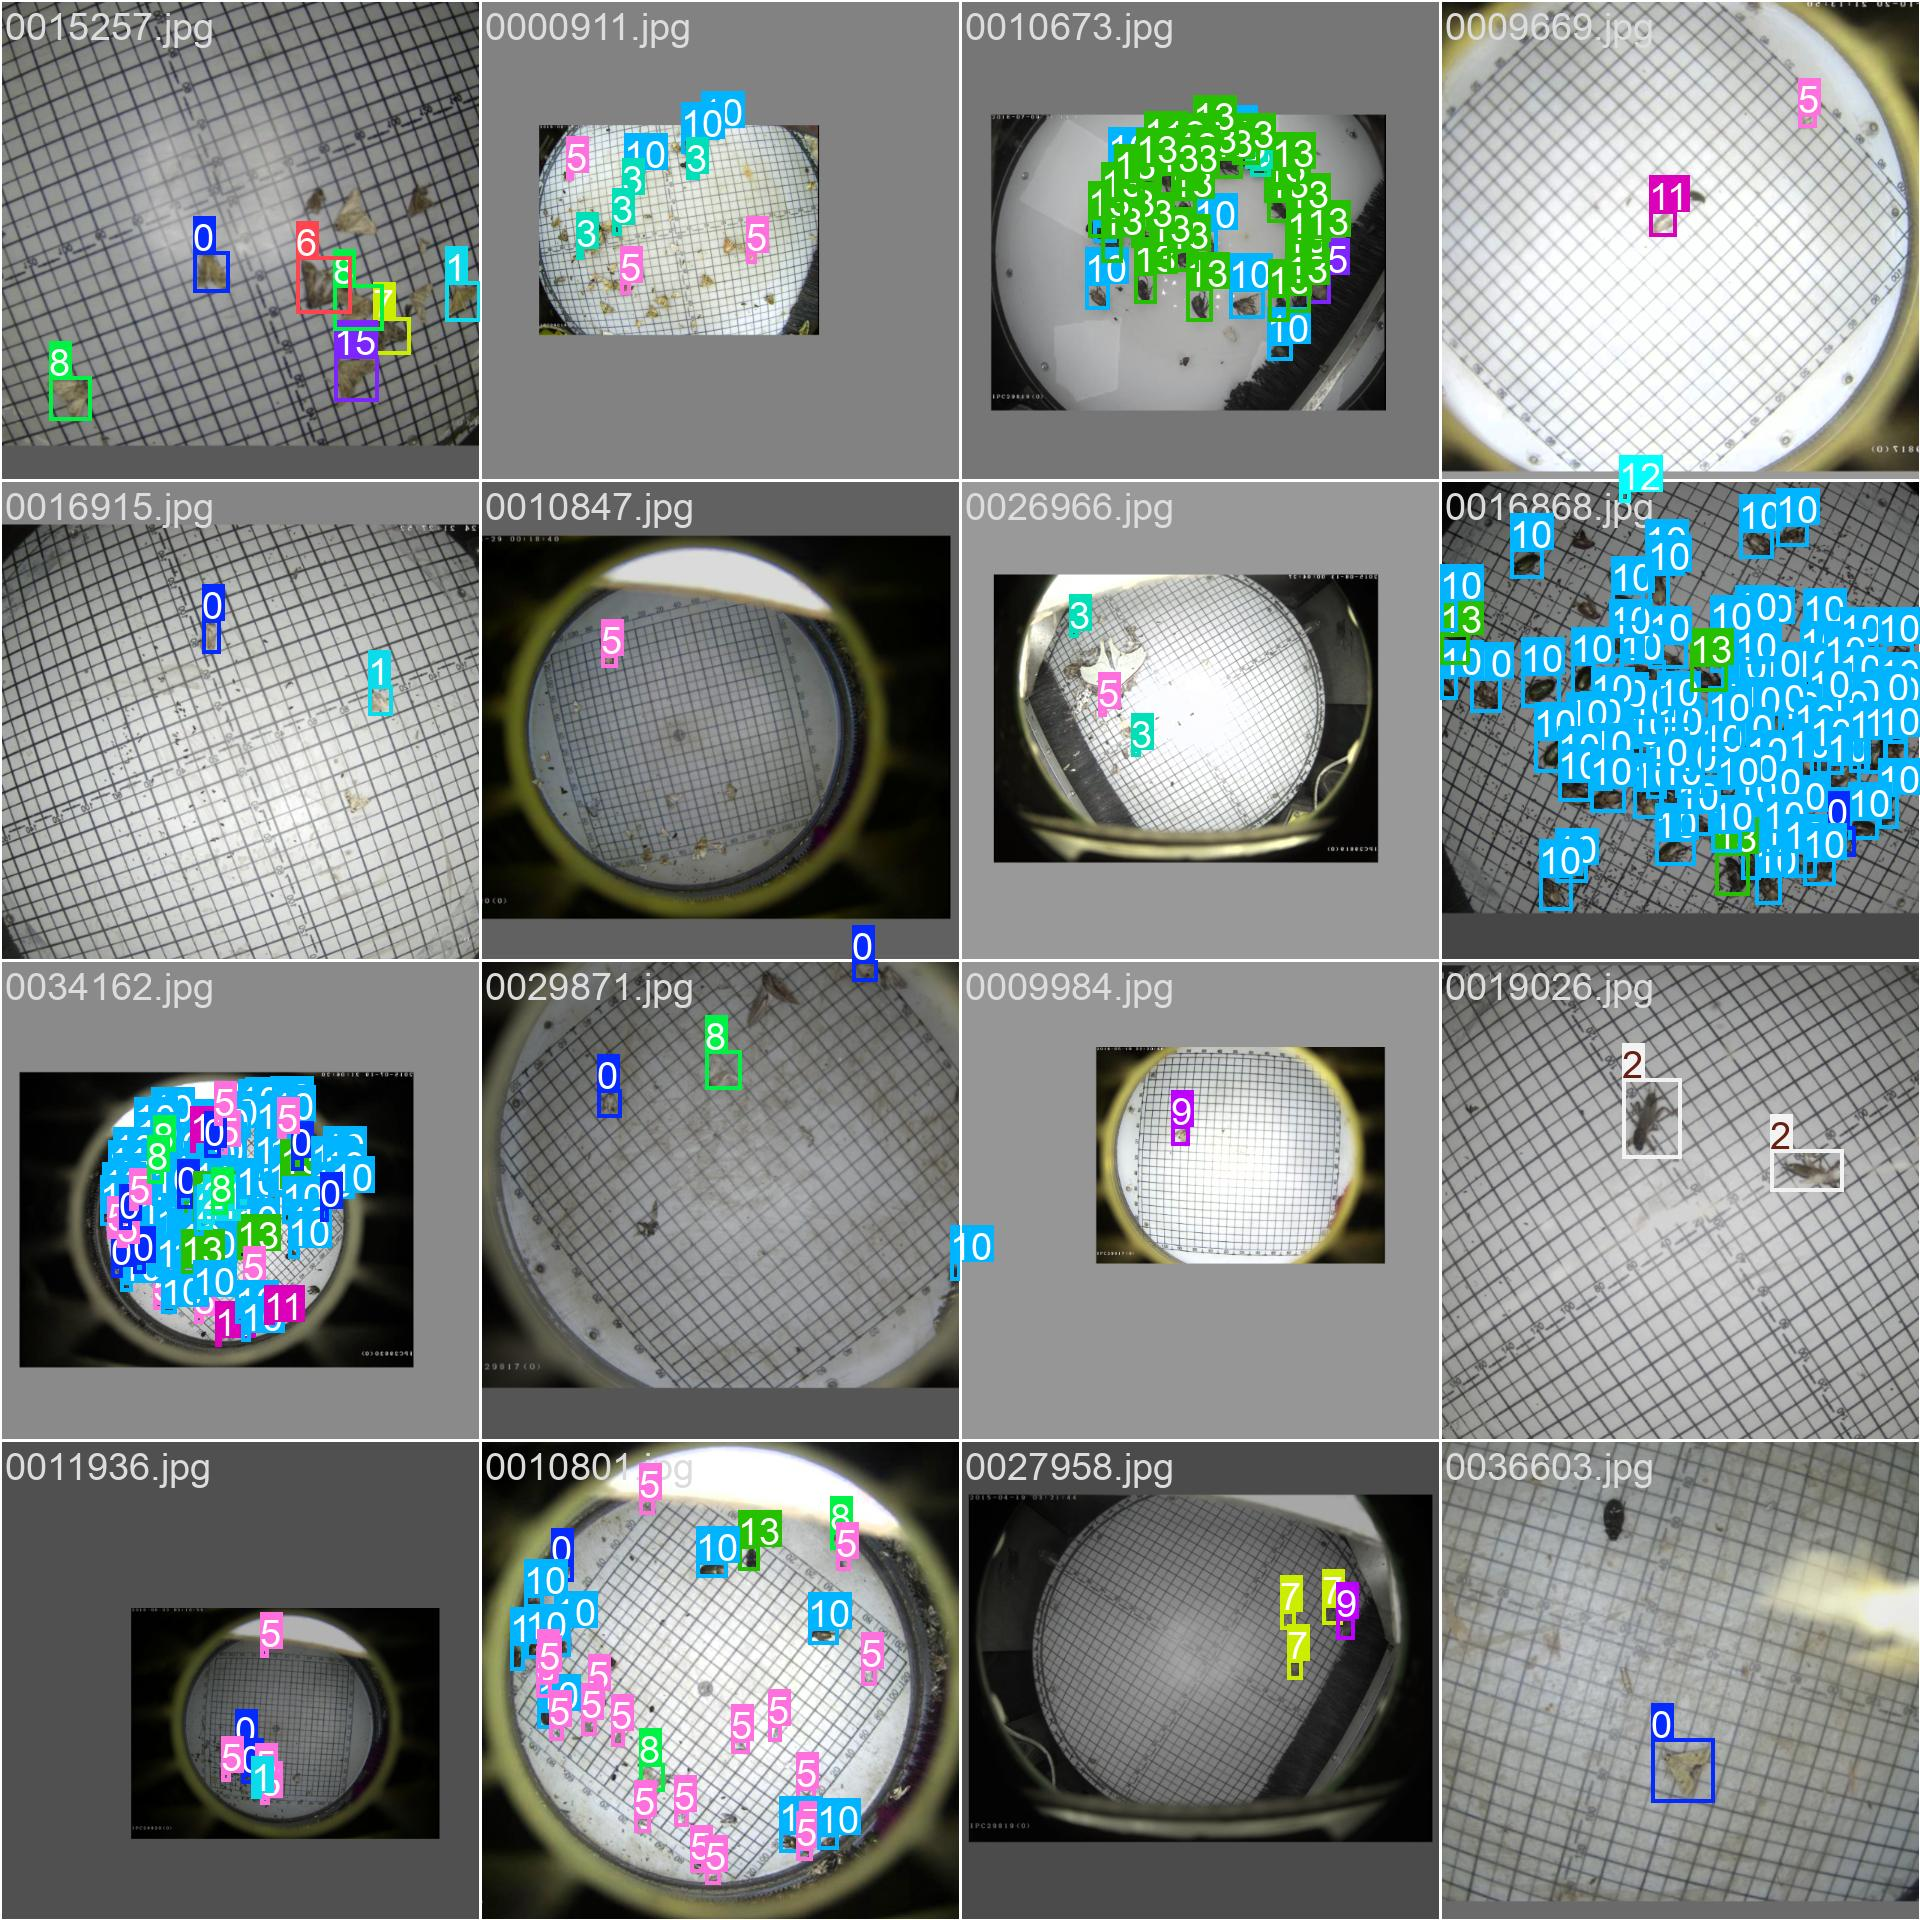

In [75]:
display(Image('/kaggle/working/runs/detect/train/train_batch2.jpg'))